In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [88]:
df = pd.read_csv("Student_Performance (1).csv")
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [7]:
print(df.shape) #check the shape of the dataframe

(25000, 16)


In [8]:
df.info() #check the information of the dataframe

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

In [9]:
df.columns #check the columns of the dataframe

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='str')

In [10]:
#data cleaning
df.isnull().sum() #no missing values

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [11]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [12]:
df.duplicated()
df.duplicated().sum()

np.int64(10000)

In [13]:
df["student_id"].duplicated().sum() #check the duplicated values in the student_id column

np.int64(10000)

In [14]:
df["student_id"].value_counts().loc[lambda x: x > 1] #check the duplicated values in the student_id column

student_id
4781     7
3073     6
3720     6
4525     6
7100     6
        ..
14989    2
14993    2
14994    2
14998    2
14999    2
Name: count, Length: 7265, dtype: int64

In [15]:
df_clean = df.drop_duplicates(
    subset=["student_id"],
    keep="first"
)
print("Before:", df.shape) #check the shape of the dataframe before dropping duplicates
print("After:", df_clean.shape) #check the shape of the dataframe after dropping duplicates
print("Duplicate student_id:", df_clean["student_id"].duplicated().sum()) #check the duplicated values in the student_id column

Before: (25000, 16)
After: (15000, 16)
Duplicate student_id: 0


In [16]:
df_clean.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,16.476400,4.25936,74.991760,63.774553,63.751227,63.709227,64.015500
std,4330.271354,1.704475,2.17244,14.401139,20.919958,21.027675,20.860201,18.977811
min,1.000000,14.000000,0.50000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3750.750000,15.000000,2.40000,62.600000,48.200000,48.100000,48.300000,49.000000
50%,7500.500000,16.000000,4.30000,75.000000,64.100000,64.000000,64.200000,64.300000
75%,11250.250000,18.000000,6.10000,87.400000,80.100000,80.100000,80.000000,79.100000
max,15000.000000,19.000000,8.00000,100.000000,100.000000,100.000000,100.000000,100.000000


In [17]:
df.select_dtypes(include="number").columns

Index(['student_id', 'age', 'study_hours', 'attendance_percentage',
       'math_score', 'science_score', 'english_score', 'overall_score'],
      dtype='str')

In [18]:
df_clean["student_id"].duplicated().sum()

np.int64(0)

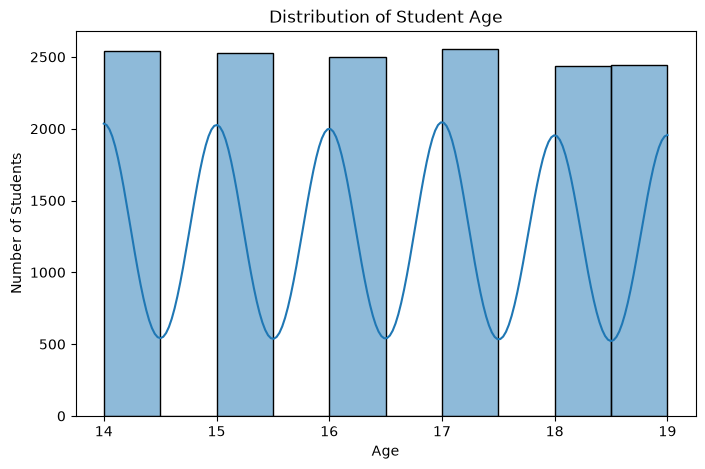

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_clean,
    x="age",
    bins=10,
    kde=True
)

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

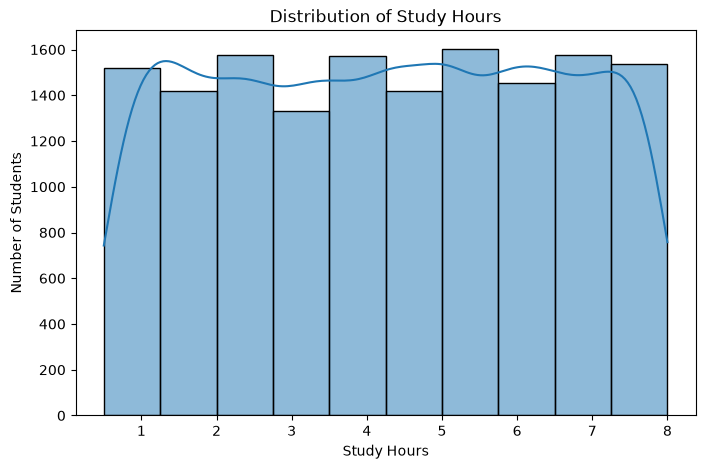

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="study_hours",
    bins=10,
    kde=True
)

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")

plt.show()

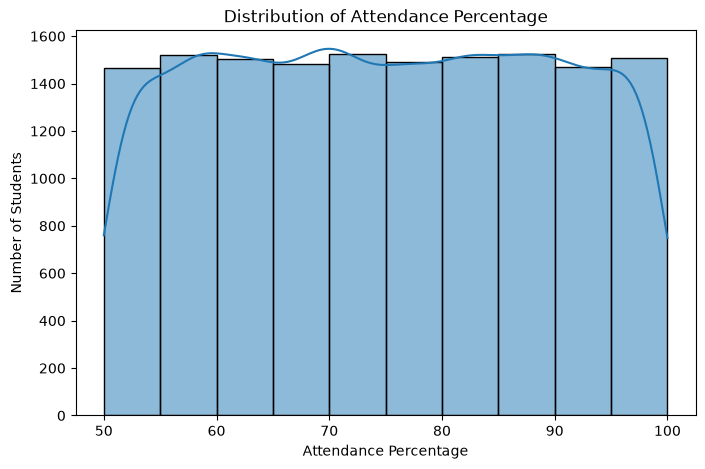

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="attendance_percentage",
    bins=10,
    kde=True
)

plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")

plt.show()

In [22]:
average_scores = df_clean[
    [
        "math_score",
        "science_score",
        "english_score",
        "overall_score"
    ]
].mean()

average_scores

math_score       63.774553
science_score    63.751227
english_score    63.709227
overall_score    64.015500
dtype: float64

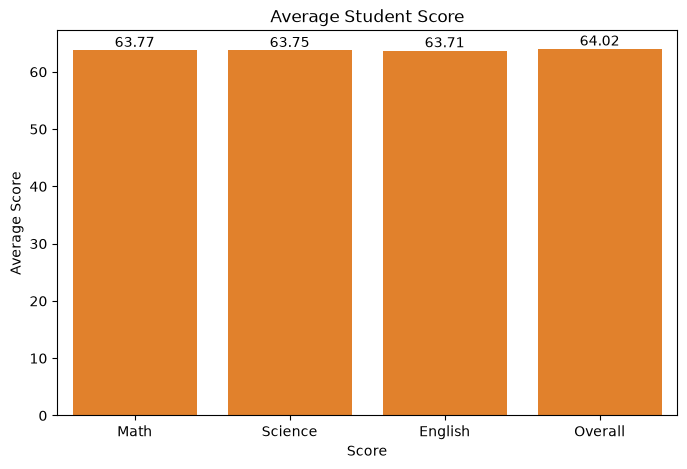

In [23]:
average_scores = df_clean[
    [
        "math_score",
        "science_score",
        "english_score",
        "overall_score"
    ]
].mean()

average_scores.index = [
    "Math",
    "Science",
    "English",
    "Overall"
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_scores.index,
    y=average_scores.values
)

plt.title("Average Student Score")
plt.xlabel("Score")
plt.ylabel("Average Score")

ax = sns.barplot(
    x=average_scores.index,
    y=average_scores.values
)
ax.bar_label(
    ax.containers[0],
    fmt="%.2f"
)

plt.show()

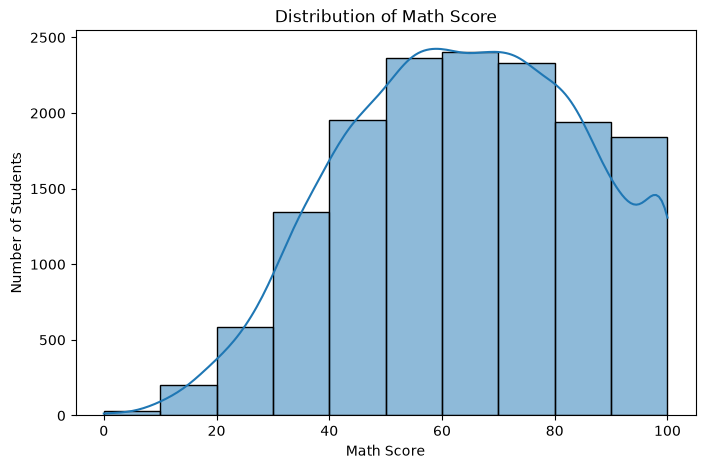

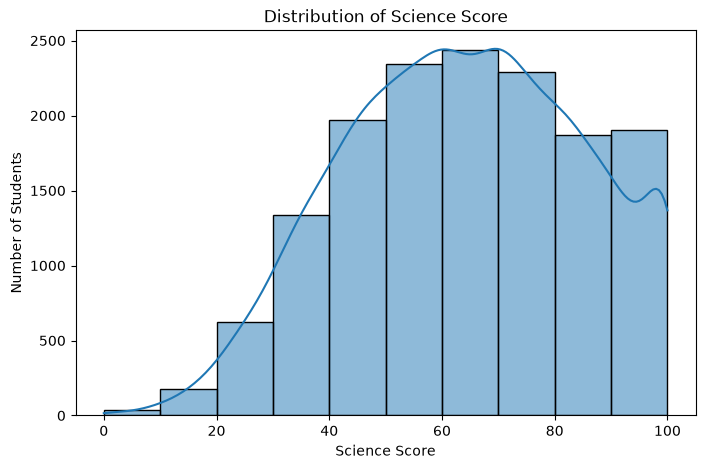

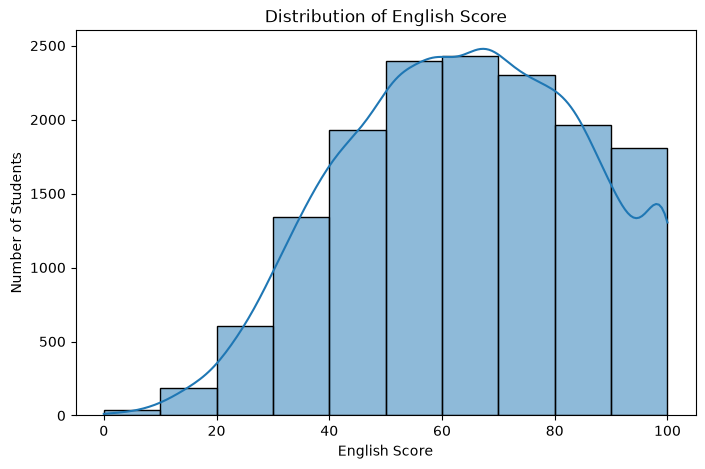

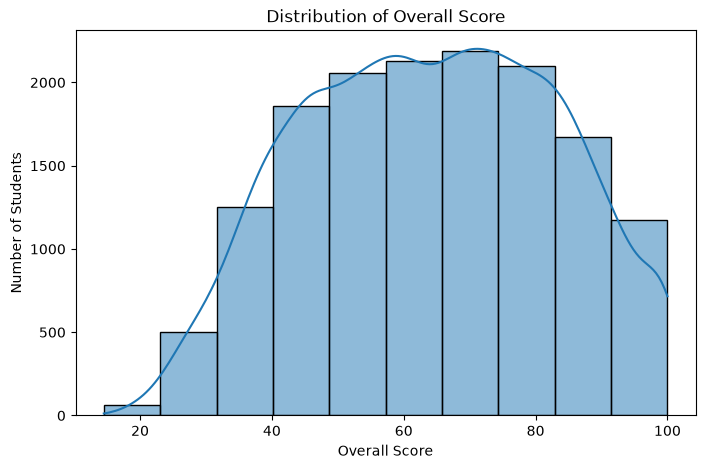

In [25]:
scores = [
    "math_score",
    "science_score",
    "english_score",
    "overall_score"
]

for score in scores:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df_clean,
        x=score,
        bins=10,
        kde=True
    )

    plt.title(f"Distribution of {score.replace('_', ' ').title()}")
    plt.xlabel(score.replace("_", " ").title())
    plt.ylabel("Number of Students")

    plt.show()

In [26]:
categorical_cols = [
    "school_type",
    "parent_education",
    "internet_access",
    "travel_time",
    "extra_activities",
    "study_method"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())


--- school_type ---
school_type
private    7587
public     7413
Name: count, dtype: int64

--- parent_education ---
parent_education
diploma          2581
post graduate    2535
high school      2532
graduate         2481
no formal        2445
phd              2426
Name: count, dtype: int64

--- internet_access ---
internet_access
yes    12754
no      2246
Name: count, dtype: int64

--- travel_time ---
travel_time
15-30 min    3823
30-60 min    3813
>60 min      3716
<15 min      3648
Name: count, dtype: int64

--- extra_activities ---
extra_activities
no     7506
yes    7494
Name: count, dtype: int64

--- study_method ---
study_method
mixed            2602
textbook         2546
notes            2515
online videos    2468
group study      2447
coaching         2422
Name: count, dtype: int64


In [27]:
for col in categorical_cols:
    print(col, ":", df_clean[col].unique())

school_type : <StringArray>
['public', 'private']
Length: 2, dtype: str
parent_education : <StringArray>
['post graduate', 'graduate', 'high school', 'no formal', 'diploma', 'phd']
Length: 6, dtype: str
internet_access : <StringArray>
['yes', 'no']
Length: 2, dtype: str
travel_time : <StringArray>
['<15 min', '>60 min', '15-30 min', '30-60 min']
Length: 4, dtype: str
extra_activities : <StringArray>
['yes', 'no']
Length: 2, dtype: str
study_method : <StringArray>
['notes', 'textbook', 'group study', 'coaching', 'mixed', 'online videos']
Length: 6, dtype: str


In [28]:
df_clean["internet_access"] = df_clean["internet_access"].map({
    "yes": 1,
    "no": 0
})

In [29]:
df_clean["extra_activities"] = df_clean["extra_activities"].map({
    "yes": 1,
    "no": 0
})

In [30]:
df_clean["school_type"] = df_clean["school_type"].map({
    "public": 0,
    "private": 1
})

In [31]:
education_mapping = {
    "no formal": 0,
    "high school": 1,
    "diploma": 2,
    "graduate": 3,
    "post graduate": 4,
    "phd": 5
}

df_clean["parent_education"] = df_clean[
    "parent_education"
].map(education_mapping)

In [32]:
travel_mapping = {
    "<15 min": 0,
    "15-30 min": 1,
    "30-60 min": 2,
    ">60 min": 3
}

df_clean["travel_time"] = df_clean[
    "travel_time"
].map(travel_mapping)

In [33]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["study_method"],
    dtype=int
)

In [34]:
df_clean["final_grade"].unique()

<StringArray>
['e', 'd', 'b', 'f', 'c', 'a']
Length: 6, dtype: str

In [35]:
grade_mapping = {
    "e": 0,
    "d": 1,
    "c": 2,
    "b": 3,
    "a": 4
}

df_clean["final_grade"] = df_clean["final_grade"].map(grade_mapping)

In [36]:
df_clean["gender"].unique()

<StringArray>
['male', 'female', 'other']
Length: 3, dtype: str

In [37]:
df_clean["gender"] = df_clean["gender"].map({
    "male": 0,
    "female": 1,
    "other": 2
})

In [38]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  15000 non-null  int64  
 1   age                         15000 non-null  int64  
 2   gender                      15000 non-null  int64  
 3   school_type                 15000 non-null  int64  
 4   parent_education            15000 non-null  int64  
 5   study_hours                 15000 non-null  float64
 6   attendance_percentage       15000 non-null  float64
 7   internet_access             15000 non-null  int64  
 8   travel_time                 15000 non-null  int64  
 9   extra_activities            15000 non-null  int64  
 10  math_score                  15000 non-null  float64
 11  science_score               15000 non-null  float64
 12  english_score               15000 non-null  float64
 13  overall_score               15000 non-null

In [39]:
df_clean.drop(
    columns=["student_id"],
    inplace=True
)

In [40]:
df_ml = df_clean.copy()
df_ml.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15000 non-null  int64  
 1   gender                      15000 non-null  int64  
 2   school_type                 15000 non-null  int64  
 3   parent_education            15000 non-null  int64  
 4   study_hours                 15000 non-null  float64
 5   attendance_percentage       15000 non-null  float64
 6   internet_access             15000 non-null  int64  
 7   travel_time                 15000 non-null  int64  
 8   extra_activities            15000 non-null  int64  
 9   math_score                  15000 non-null  float64
 10  science_score               15000 non-null  float64
 11  english_score               15000 non-null  float64
 12  overall_score               15000 non-null  float64
 13  final_grade                 13204 non-null

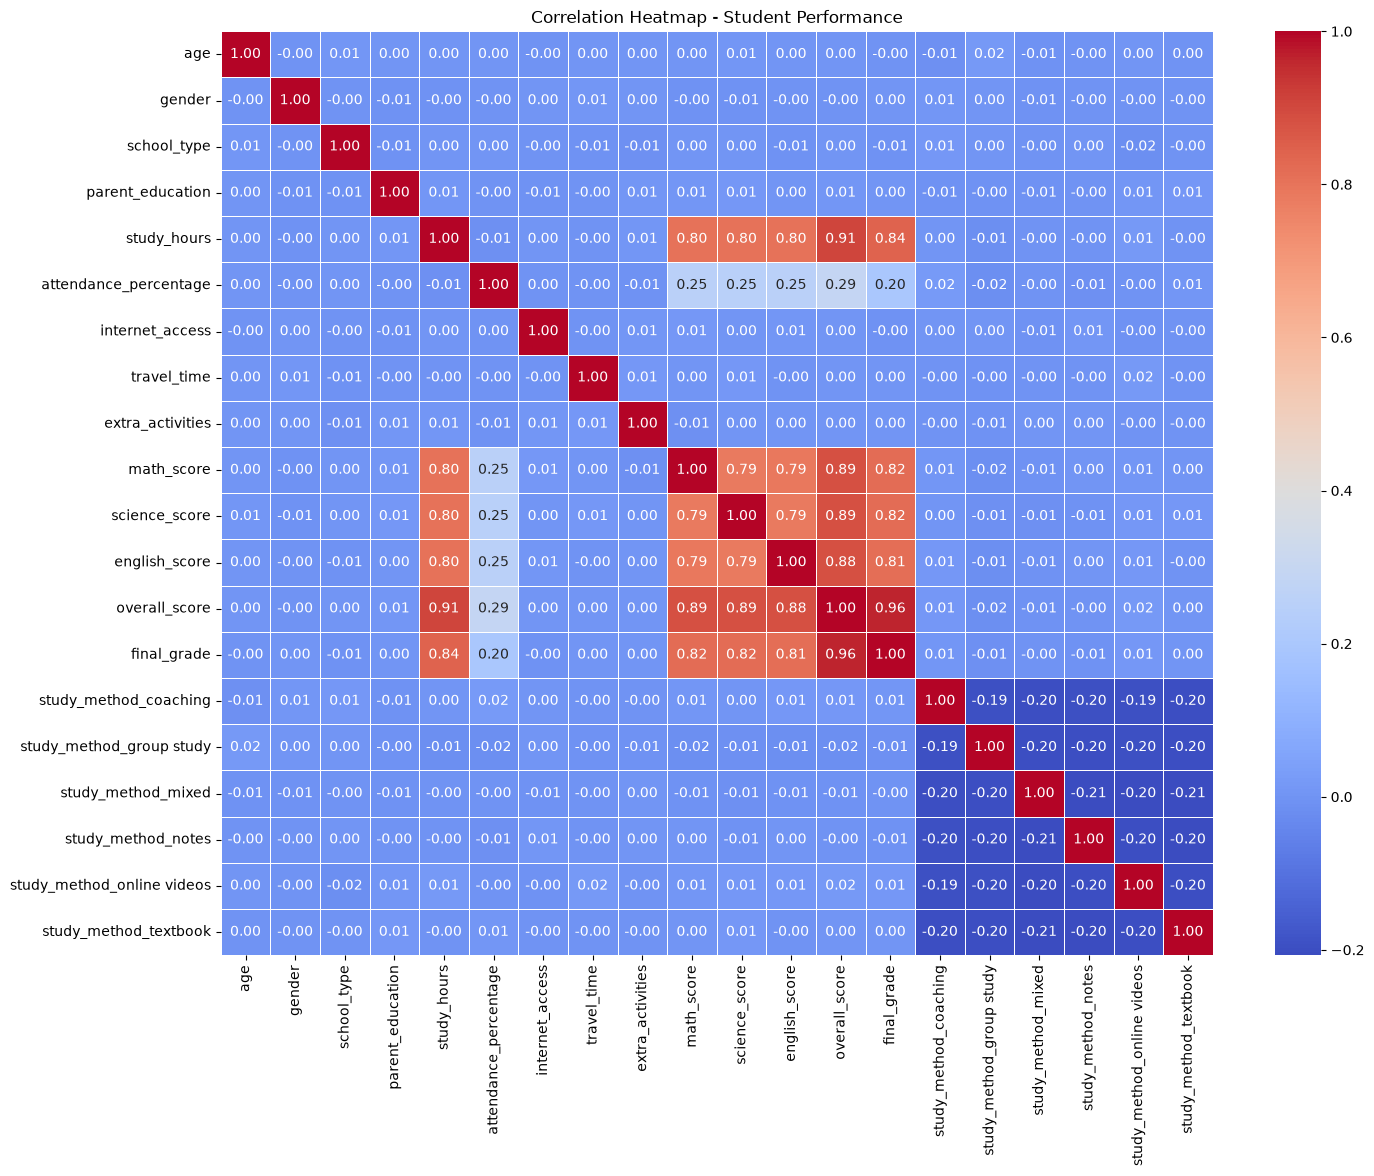

In [41]:
numeric_cols = [
    "age",
    "gender",
    "school_type",
    "parent_education",
    "study_hours",
    "attendance_percentage",
    "internet_access",
    "travel_time",
    "extra_activities",
    "math_score",
    "science_score",
    "english_score",
    "overall_score",
    "final_grade",
    "study_method_coaching",
    "study_method_group study",
    "study_method_mixed",
    "study_method_notes",
    "study_method_online videos",
    "study_method_textbook"
]

correlation = df_ml[numeric_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Student Performance")

plt.show()

In [42]:
correlation = df_ml[numeric_cols].corr()
correlation

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,math_score,science_score,english_score,overall_score,final_grade,study_method_coaching,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
age,1.000000,-0.004020,0.005441,0.001276,0.004240,0.004521,-0.003399,0.004151,0.001553,0.000575,0.008525,0.002694,0.004981,-0.001307,-0.011145,0.016117,-0.006053,-0.003575,0.004773,0.000009
gender,-0.004020,1.000000,-0.001120,-0.006260,-0.004451,-0.000073,0.004442,0.006915,0.004653,-0.004838,-0.007584,-0.002104,-0.004330,0.000707,0.006612,0.003912,-0.006231,-0.000996,-0.000740,-0.002323
school_type,0.005441,-0.001120,1.000000,-0.007980,0.002991,0.004858,-0.000737,-0.005234,-0.013192,0.000703,0.000860,-0.005503,0.001112,-0.006821,0.011217,0.004802,-0.000032,0.003538,-0.017016,-0.002404
parent_education,0.001276,-0.006260,-0.007980,1.000000,0.008802,-0.001409,-0.008809,-0.002990,0.006171,0.006449,0.012541,0.002190,0.008172,0.002448,-0.008334,-0.004824,-0.007256,-0.000095,0.006396,0.014015
study_hours,0.004240,-0.004451,0.002991,0.008802,1.000000,-0.009486,0.002187,-0.000709,0.008210,0.802971,0.804551,0.804208,0.905885,0.842449,0.004189,-0.014747,-0.002865,-0.000369,0.014775,-0.000926
attendance_percentage,0.004521,-0.000073,0.004858,-0.001409,-0.009486,1.000000,0.000154,-0.001391,-0.008395,0.252210,0.248960,0.253859,0.288473,0.195809,0.023136,-0.016494,-0.000540,-0.013365,-0.001791,0.009170
internet_access,-0.003399,0.004442,-0.000737,-0.008809,0.002187,0.000154,1.000000,-0.004289,0.007138,0.011499,0.001691,0.005276,0.003525,-0.004583,0.002871,0.003741,-0.005622,0.006292,-0.004766,-0.002379
travel_time,0.004151,0.006915,-0.005234,-0.002990,-0.000709,-0.001391,-0.004289,1.000000,0.010636,0.002724,0.009836,-0.002032,0.001259,0.004118,-0.001741,-0.004930,-0.003938,-0.003982,0.015235,-0.000554
extra_activities,0.001553,0.004653,-0.013192,0.006171,0.008210,-0.008395,0.007138,0.010636,1.000000,-0.010612,0.003149,0.001586,0.002448,0.002590,-0.000736,-0.005240,0.004592,0.003393,-0.001803,-0.000349
math_score,0.000575,-0.004838,0.000703,0.006449,0.802971,0.252210,0.011499,0.002724,-0.010612,1.000000,0.785904,0.788176,0.885394,0.818099,0.009298,-0.017179,-0.007123,0.004539,0.007844,0.002715


In [ ]:
Data Cleaning ✅
      ↓
EDA & Data Visualization ✅
      ↓
Feature Selection
      ↓
Preprocessing
      ↓
Train-Test Split
      ↓
Machine Learning Model
      ↓
Evaluation
      ↓
Model Comparison
      ↓
Conclusion

In [43]:
df_ml = df_ml.dropna(subset=["final_grade"])

In [45]:
#declare the target variable and features
target = "final_grade"

features = [
    col for col in df_ml.columns
    if col not in [target, "overall_score"]
]

X = df_ml[features]
y = df_ml[target]
print("Target:", target)
print("Jumlah features:", len(features))
print("Features:")
print(features)

Target: final_grade
Jumlah features: 18
Features:
['age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'math_score', 'science_score', 'english_score', 'study_method_coaching', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook']


In [46]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\juliy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [47]:
# train-test split
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10563, 18)
X_test : (2641, 18)
y_train: (10563,)
y_test : (2641,)


In [50]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Original:
final_grade
1.0    0.285520
2.0    0.279991
0.0    0.255832
3.0    0.124053
4.0    0.054605
Name: proportion, dtype: float64

Training:
final_grade
1.0    0.285525
2.0    0.280034
0.0    0.255799
3.0    0.124018
4.0    0.054625
Name: proportion, dtype: float64

Testing:
final_grade
1.0    0.285498
2.0    0.279818
0.0    0.255964
3.0    0.124195
4.0    0.054525
Name: proportion, dtype: float64


In [51]:
# Model 1 logistic regression
from sklearn.linear_model import LogisticRegression

In [52]:
model_lr = LogisticRegression(max_iter=1000)

In [53]:
model_lr.fit(X_train, y_train)

C:\Users\juliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [54]:
y_pred_lr = model_lr.predict(X_test)

In [55]:
print(y_pred_lr[:10])

[0. 2. 3. 0. 1. 1. 2. 3. 0. 2.]


In [56]:
#accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.6539189700870882


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82       676
         1.0       0.69      0.66      0.67       754
         2.0       0.61      0.70      0.65       739
         3.0       0.40      0.37      0.39       328
         4.0       0.35      0.22      0.27       144

    accuracy                           0.65      2641
   macro avg       0.57      0.56      0.56      2641
weighted avg       0.65      0.65      0.65      2641



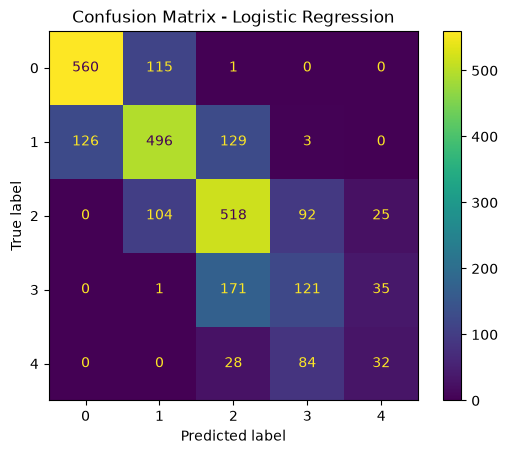

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The Logistic Regression model achieved an accuracy of 65.39% on the test set. The model performed best for grade 0, with an F1-score of 0.82, while its performance decreased considerably for higher grades. Grade 4 had the lowest F1-score (0.27) and recall (0.22), indicating that the model struggled to correctly identify students in the highest grade category. The relatively small number of grade 3 and grade 4 observations may contribute to this lower performance.

In [59]:
# Model 2 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier 
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [60]:
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [61]:
y_pred_rf = model_rf.predict(X_test)
print(y_pred_rf[:10])

[1. 2. 3. 0. 1. 1. 2. 3. 0. 2.]


In [62]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7739492616433169


In [63]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.86      0.89      0.88       676
         1.0       0.79      0.76      0.78       754
         2.0       0.75      0.79      0.77       739
         3.0       0.59      0.61      0.60       328
         4.0       0.81      0.58      0.67       144

    accuracy                           0.77      2641
   macro avg       0.76      0.73      0.74      2641
weighted avg       0.77      0.77      0.77      2641



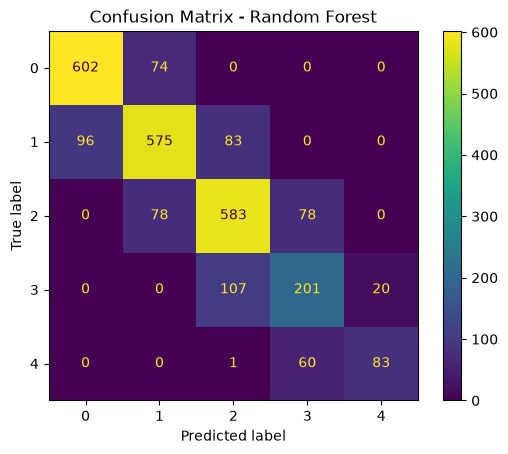

In [65]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [64]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy      :", accuracy_rf)

Logistic Regression Accuracy: 0.6539189700870882
Random Forest Accuracy      : 0.7739492616433169


Random Forest outperformed Logistic Regression in predicting students' final grades. Random Forest achieved an accuracy of 77%, compared with 65.39% for Logistic Regression. The macro F1-score also increased from 0.56 to 0.74, indicating better and more balanced classification performance across the five grade categories. The model performed particularly well for grades 0, 1, and 2, while grades 3 and 4 remained more challenging to classify. The lower recall for grade 4 may be partly related to its relatively small number of observations in the dataset.

In [66]:
importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(importance)


study_hours                   0.234272
math_score                    0.175433
science_score                 0.175197
english_score                 0.164700
attendance_percentage         0.089253
parent_education              0.027602
age                           0.027495
travel_time                   0.021792
gender                        0.016386
school_type                   0.010220
extra_activities              0.010192
internet_access               0.007313
study_method_coaching         0.007129
study_method_online videos    0.006897
study_method_mixed            0.006742
study_method_textbook         0.006670
study_method_group study      0.006355
study_method_notes            0.006353
dtype: float64


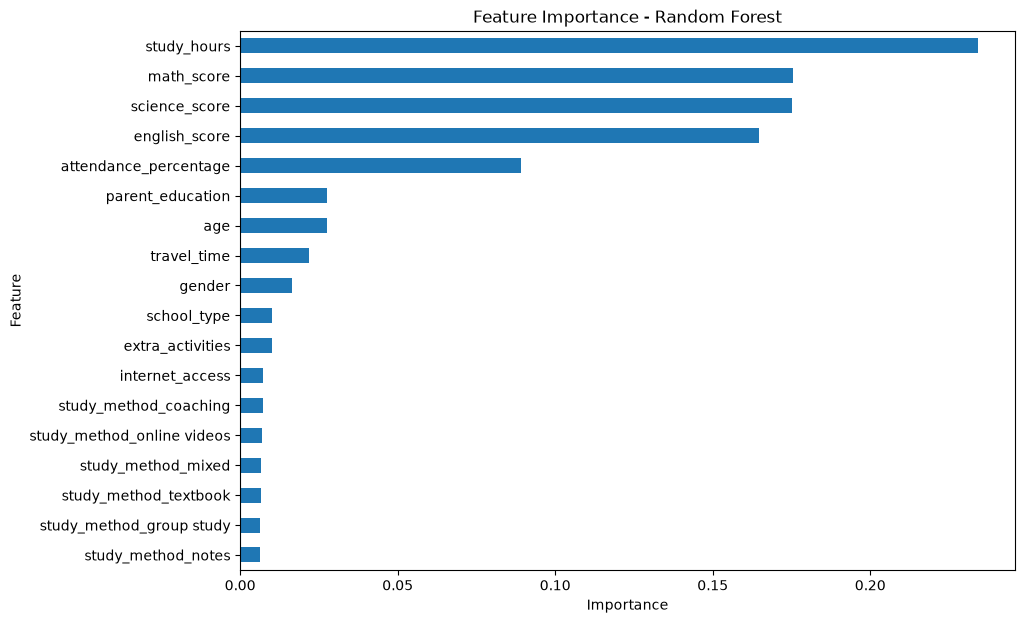

In [67]:
plt.figure(figsize=(10, 7))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [69]:
target = "final_grade"

drop_cols = [
    "final_grade",
    "math_score",
    "science_score",
    "english_score",
    "overall_score"
]

features_model2 = [
    col for col in df_ml.columns
    if col not in drop_cols
]

X2 = df_ml[features_model2]
y2 = df_ml[target]
print("Features Model 2:")
print(features_model2)

print("\nX2 shape:", X2.shape)
print("y2 shape:", y2.shape)

Features Model 2:
['age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method_coaching', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook']

X2 shape: (13204, 15)
y2 shape: (13204,)


In [71]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)
print("X2_train:", X2_train.shape)
print("X2_test :", X2_test.shape)
print("y2_train:", y2_train.shape)
print("y2_test :", y2_test.shape)

X2_train: (10563, 15)
X2_test : (2641, 15)
y2_train: (10563,)
y2_test : (2641,)


In [ ]:
# Model 2 Logistic Regression part 2
model_lr2 = LogisticRegression(
    max_iter=1000
)
model_lr2.fit(X2_train, y2_train)
y2_pred_lr = model_lr2.predict(X2_test)

C:\Users\juliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
accuracy_lr2 = accuracy_score(
    y2_test,
    y2_pred_lr
)

print("Logistic Regression Model 2")
print("Accuracy:", accuracy_lr2)

print("\nClassification Report:")
print(classification_report(
    y2_test,
    y2_pred_lr
))

Logistic Regression Model 2
Accuracy: 0.6773949261643317

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82       676
         1.0       0.69      0.67      0.68       754
         2.0       0.66      0.75      0.70       739
         3.0       0.44      0.41      0.43       328
         4.0       0.46      0.24      0.32       144

    accuracy                           0.68      2641
   macro avg       0.61      0.58      0.59      2641
weighted avg       0.67      0.68      0.67      2641



In [75]:
model_rf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf2.fit(X2_train, y2_train)
y2_pred_rf = model_rf2.predict(X2_test)

In [76]:
accuracy_rf2 = accuracy_score(
    y2_test,
    y2_pred_rf
)

print("Random Forest Model 2")
print("Accuracy:", accuracy_rf2)

print("\nClassification Report:")
print(classification_report(
    y2_test,
    y2_pred_rf
))

Random Forest Model 2
Accuracy: 0.6512684589170769

Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81       676
         1.0       0.66      0.61      0.64       754
         2.0       0.61      0.75      0.67       739
         3.0       0.42      0.31      0.36       328
         4.0       0.49      0.33      0.39       144

    accuracy                           0.65      2641
   macro avg       0.60      0.56      0.57      2641
weighted avg       0.64      0.65      0.64      2641



In [77]:
results_model2 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr2,
        accuracy_rf2
    ]
})

print(results_model2)

                 Model  Accuracy
0  Logistic Regression  0.677395
1        Random Forest  0.651268


In [78]:
from sklearn.metrics import f1_score

f1_lr2 = f1_score(
    y2_test,
    y2_pred_lr,
    average="macro"
)

f1_rf2 = f1_score(
    y2_test,
    y2_pred_rf,
    average="macro"
)

results_model2 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr2,
        accuracy_rf2
    ],
    "Macro F1": [
        f1_lr2,
        f1_rf2
    ]
})

print(results_model2)

                 Model  Accuracy  Macro F1
0  Logistic Regression  0.677395  0.589758
1        Random Forest  0.651268  0.573857


Subject scores are highly informative for predicting final grade. When Math, Science, and English scores are removed, model performance decreases, particularly for Random Forest. However, study behavior and demographic variables still provide meaningful predictive information, with Logistic Regression achieving 67.74% accuracy.

In [79]:
importance_rf2 = pd.Series(
    model_rf2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

print(importance_rf2)

study_hours                   0.448883
attendance_percentage         0.196038
age                           0.070457
parent_education              0.068132
travel_time                   0.051776
gender                        0.038504
school_type                   0.023179
extra_activities              0.021971
internet_access               0.015561
study_method_mixed            0.011444
study_method_online videos    0.011342
study_method_textbook         0.011137
study_method_coaching         0.010990
study_method_notes            0.010918
study_method_group study      0.009667
dtype: float64


In [80]:
feature_importance_rf2 = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": model_rf2.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_rf2)

                       Feature  Importance
4                  study_hours    0.448883
5        attendance_percentage    0.196038
0                          age    0.070457
3             parent_education    0.068132
7                  travel_time    0.051776
1                       gender    0.038504
2                  school_type    0.023179
8             extra_activities    0.021971
6              internet_access    0.015561
11          study_method_mixed    0.011444
13  study_method_online videos    0.011342
14       study_method_textbook    0.011137
9        study_method_coaching    0.010990
12          study_method_notes    0.010918
10    study_method_group study    0.009667


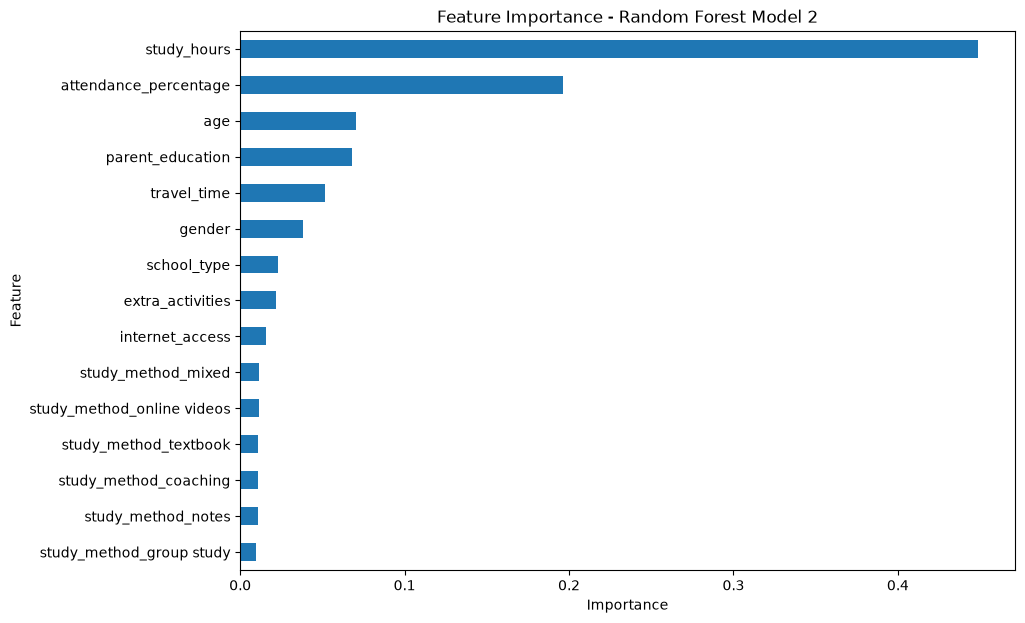

In [81]:
plt.figure(figsize=(10, 7))
importance_rf2.sort_values().plot(
    kind="barh"
)
plt.title("Feature Importance - Random Forest Model 2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The Random Forest feature importance analysis shows that study hours is the most important predictor of final grade, contributing approximately 44.89% of the total feature importance. Attendance percentage is the second most important feature at 19.60%. Together, study hours and attendance account for approximately 64.49% of the model's feature importance. Other factors, including age, parent education, travel time, gender, and school type, have considerably smaller contributions. The individual study method categories have the lowest importance, suggesting that the type of study method itself contributes relatively little to the model's prediction compared with study duration and attendance.

In [82]:
coefficients_lr2 = pd.DataFrame(
    model_lr2.coef_,
    columns=X2.columns
)

print(coefficients_lr2)

        age    gender  school_type  parent_education  study_hours  \
0  0.073853 -0.057452     0.045492          0.022677    -4.228073   
1  0.119483  0.007300     0.123179          0.051615    -1.659428   
2  0.041108 -0.005328     0.015191         -0.007989     0.523348   
3  0.034254  0.019546     0.019429          0.019709     2.436389   
4 -0.268697  0.035933    -0.203292         -0.086012     2.927765   

   attendance_percentage  internet_access  travel_time  extra_activities  \
0              -0.211601         0.041307     0.042070          0.144746   
1              -0.081090         0.191224     0.010686          0.076898   
2               0.027471        -0.025221    -0.011712         -0.106583   
3               0.111280        -0.153304     0.030891          0.089568   
4               0.153940        -0.054005    -0.071934         -0.204630   

   study_method_coaching  study_method_group study  study_method_mixed  \
0               4.617063                  4.674613    

In [83]:
coefficients_lr2.index = model_lr2.classes_
print(coefficients_lr2)

          age    gender  school_type  parent_education  study_hours  \
0.0  0.073853 -0.057452     0.045492          0.022677    -4.228073   
1.0  0.119483  0.007300     0.123179          0.051615    -1.659428   
2.0  0.041108 -0.005328     0.015191         -0.007989     0.523348   
3.0  0.034254  0.019546     0.019429          0.019709     2.436389   
4.0 -0.268697  0.035933    -0.203292         -0.086012     2.927765   

     attendance_percentage  internet_access  travel_time  extra_activities  \
0.0              -0.211601         0.041307     0.042070          0.144746   
1.0              -0.081090         0.191224     0.010686          0.076898   
2.0               0.027471        -0.025221    -0.011712         -0.106583   
3.0               0.111280        -0.153304     0.030891          0.089568   
4.0               0.153940        -0.054005    -0.071934         -0.204630   

     study_method_coaching  study_method_group study  study_method_mixed  \
0.0               4.617063  

In [84]:
coefficients_lr2 = pd.DataFrame(
    model_lr2.coef_,
    columns=X2.columns,
    index=[f"Grade {c}" for c in model_lr2.classes_]
)
coefficients_lr2

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method_coaching,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
Grade 0.0,0.073853,-0.057452,0.045492,0.022677,-4.228073,-0.211601,0.041307,0.042070,0.144746,4.617063,4.674613,4.537440,4.403468,4.551072,4.553045
Grade 1.0,0.119483,0.007300,0.123179,0.051615,-1.659428,-0.081090,0.191224,0.010686,0.076898,1.898924,2.083344,1.968548,2.059106,2.172323,1.976636
Grade 2.0,0.041108,-0.005328,0.015191,-0.007989,0.523348,0.027471,-0.025221,-0.011712,-0.106583,-0.208262,-0.384104,-0.269475,-0.238581,-0.395393,-0.336412
Grade 3.0,0.034254,0.019546,0.019429,0.019709,2.436389,0.111280,-0.153304,0.030891,0.089568,-3.027097,-3.237477,-2.831892,-2.769096,-2.926600,-3.055903
Grade 4.0,-0.268697,0.035933,-0.203292,-0.086012,2.927765,0.153940,-0.054005,-0.071934,-0.204630,-3.280628,-3.136376,-3.404620,-3.454898,-3.401402,-3.137367


In [85]:
coef_importance = pd.DataFrame(
    abs(model_lr2.coef_),
    columns=X2.columns
)

coef_importance = coef_importance.mean().sort_values(
    ascending=False
)

print(coef_importance)

study_method_group study      2.703183
study_method_online videos    2.689358
study_method_textbook         2.611873
study_method_coaching         2.606395
study_method_mixed            2.602395
study_method_notes            2.585030
study_hours                   2.355000
extra_activities              0.124485
attendance_percentage         0.117076
age                           0.107479
internet_access               0.093012
school_type                   0.081317
parent_education              0.037600
travel_time                   0.033458
gender                        0.025112
dtype: float64


In [86]:
coefficients_lr2 = pd.DataFrame(
    model_lr2.coef_,
    columns=X2.columns,
    index=[f"Grade {c}" for c in model_lr2.classes_]
)

coefficients_lr2

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method_coaching,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
Grade 0.0,0.073853,-0.057452,0.045492,0.022677,-4.228073,-0.211601,0.041307,0.042070,0.144746,4.617063,4.674613,4.537440,4.403468,4.551072,4.553045
Grade 1.0,0.119483,0.007300,0.123179,0.051615,-1.659428,-0.081090,0.191224,0.010686,0.076898,1.898924,2.083344,1.968548,2.059106,2.172323,1.976636
Grade 2.0,0.041108,-0.005328,0.015191,-0.007989,0.523348,0.027471,-0.025221,-0.011712,-0.106583,-0.208262,-0.384104,-0.269475,-0.238581,-0.395393,-0.336412
Grade 3.0,0.034254,0.019546,0.019429,0.019709,2.436389,0.111280,-0.153304,0.030891,0.089568,-3.027097,-3.237477,-2.831892,-2.769096,-2.926600,-3.055903
Grade 4.0,-0.268697,0.035933,-0.203292,-0.086012,2.927765,0.153940,-0.054005,-0.071934,-0.204630,-3.280628,-3.136376,-3.404620,-3.454898,-3.401402,-3.137367


In [87]:
for grade in coefficients_lr2.index:
    print(f"\n{grade}")
    print(
        coefficients_lr2.loc[grade]
        .sort_values()
    )


Grade 0.0
study_hours                  -4.228073
attendance_percentage        -0.211601
gender                       -0.057452
parent_education              0.022677
internet_access               0.041307
travel_time                   0.042070
school_type                   0.045492
age                           0.073853
extra_activities              0.144746
study_method_notes            4.403468
study_method_mixed            4.537440
study_method_online videos    4.551072
study_method_textbook         4.553045
study_method_coaching         4.617063
study_method_group study      4.674613
Name: Grade 0.0, dtype: float64

Grade 1.0
study_hours                  -1.659428
attendance_percentage        -0.081090
gender                        0.007300
travel_time                   0.010686
parent_education              0.051615
extra_activities              0.076898
age                           0.119483
school_type                   0.123179
internet_access               0.191224
study_meth

in model 2, where subject scores and overall score were excluded, study behavior became the most important source of predictive information. Random Forest identified study hours as the most important feature (44.89%), followed by attendance percentage (19.60%). Logistic Regression showed a consistent pattern, where higher study hours were associated with a greater likelihood of higher grades, while lower study hours were associated with lower grades. Attendance percentage showed a similar but weaker pattern. Demographic variables such as age, gender, school type, and parent education had relatively smaller effects.

I analyzed a Student Performance Dataset to identify factors associated with students' final grades and build a classification model. After cleaning and encoding the data, I compared Logistic Regression and Random Forest. Random Forest performed best when academic scores were included, achieving 77% accuracy and a 0.74 macro F1-score. I then created a second model without Math, Science, English, and Overall scores to avoid relying on existing academic performance. In this scenario, Logistic Regression achieved 67.74% accuracy. Feature analysis showed that study hours and attendance were the most important predictors, contributing 44.89% and 19.60% respectively in the Random Forest model. Overall, the analysis indicates that study behavior, especially study time and attendance, provides meaningful information for predicting students' final grades.